In [1]:
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
)

import matplotlib.pyplot as plt

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Inliers
# Generate 1,000 normal data points sampled from a 2D Gaussian (normal) distribution
n_inliers = 1000
X_in = np.random.normal(loc=0.0, scale=1.0, size=(n_inliers, 2))

# Outliers
# Generate 50 anomalous points using a uniform distribution
# Values are sampled randomly between −8 and 8
n_outliers = 50
X_out = np.random.uniform(low=-8, high=8, size=(n_outliers, 2))

X = np.vstack([X_in, X_out])
# The labels are for evaluation only
y = np.hstack([np.zeros(n_inliers, dtype=int), np.ones(n_outliers, dtype=int)])  # 0=inlier, 1=outlier

df = pd.DataFrame(X, columns=["x1", "x2"])
df["is_outlier"] = y

print(df.head())
print("\nClass balance:")
print(df["is_outlier"].value_counts(normalize=True).rename("proportion"))

         x1        x2  is_outlier
0  0.496714 -0.138264           0
1  0.647689  1.523030           0
2 -0.234153 -0.234137           0
3  1.579213  0.767435           0
4 -0.469474  0.542560           0

Class balance:
is_outlier
0    0.952381
1    0.047619
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["x1", "x2"]].values,
    df["is_outlier"].values,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["is_outlier"].values,
)

In [5]:
# Fit Isolation Forest
contamination_guess = 0.05
model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("iforest", IsolationForest(
            n_estimators=300,
            contamination=contamination_guess,
            max_samples="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]
)
model.fit(X_train)

,steps,"[('scaler', ...), ('iforest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,max_samples,'auto'
,contamination,0.05
,max_features,1.0


In [6]:
pred_test_raw = model.predict(X_test)
y_pred_test = (pred_test_raw == -1).astype(int)  # convert to 1=outlier, 0=inlier

# decision_function: higher means more "normal"
# To make "outlier score" where higher = more anomalous, we invert sign.
normality_score_test = model.decision_function(X_test)
outlier_score_test = -normality_score_test

In [7]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion matrix:\n", cm)

print("\nClassification report (outlier=1):")
print(classification_report(y_test, y_pred_test, digits=4))

auc = roc_auc_score(y_test, outlier_score_test)
print(f"ROC AUC: {auc:.4f}")


Confusion matrix:
 [[297   3]
 [  1  14]]

Classification report (outlier=1):
              precision    recall  f1-score   support

           0     0.9966    0.9900    0.9933       300
           1     0.8235    0.9333    0.8750        15

    accuracy                         0.9873       315
   macro avg     0.9101    0.9617    0.9342       315
weighted avg     0.9884    0.9873    0.9877       315

ROC AUC: 0.9993


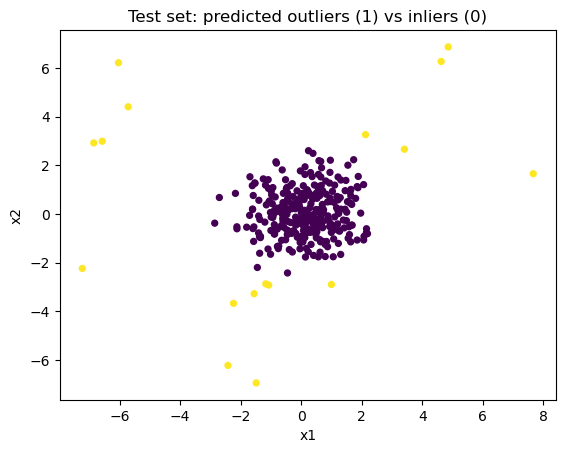

In [8]:
plt.figure()
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_test, s=18)
plt.title("Test set: predicted outliers (1) vs inliers (0)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

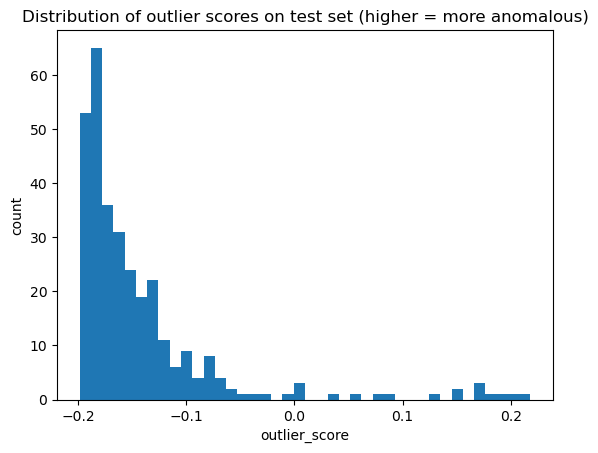

In [9]:
plt.figure()
plt.hist(outlier_score_test, bins=40)
plt.title("Distribution of outlier scores on test set (higher = more anomalous)")
plt.xlabel("outlier_score")
plt.ylabel("count")
plt.show()

In [10]:
k = 10
top_idx = np.argsort(outlier_score_test)[-k:][::-1]
top_df = pd.DataFrame(X_test, columns=["x1", "x2"]).iloc[top_idx].copy()
top_df["outlier_score"] = outlier_score_test[top_idx]
top_df["true_outlier"] = y_test[top_idx]
top_df["pred_outlier"] = y_pred_test[top_idx]
print("\nTop most anomalous test points:")
print(top_df)


Top most anomalous test points:
           x1        x2  outlier_score  true_outlier  pred_outlier
277 -6.033269  6.218545       0.218253             1             1
126  4.855724  6.867649       0.206411             1             1
107  4.622920  6.269954       0.194557             1             1
40  -5.713985  4.405538       0.182924             1             1
53  -6.851587  2.921876       0.174684             1             1
9   -7.229024 -2.239193       0.174125             1             1
122 -6.571368  2.992308       0.171690             1             1
2   -2.418871 -6.224030       0.152046             1             1
208 -1.486296 -6.943842       0.152045             1             1
197  7.663698  1.655890       0.128636             1             1


In [11]:
# Prediction Example
x_new = np.array([[3.5, 3.5], [0.1, -0.1]])
pred_new_raw = model.predict(x_new)
pred_new = (pred_new_raw == -1).astype(int)
score_new = -model.decision_function(x_new)

print("New points prediction:")
for i in range(x_new.shape[0]):
    print(f"x={x_new[i]} -> pred_outlier={pred_new[i]} (1=outlier), outlier_score={score_new[i]:.4f}")

New points prediction:
x=[3.5 3.5] -> pred_outlier=1 (1=outlier), outlier_score=0.1107
x=[ 0.1 -0.1] -> pred_outlier=0 (1=outlier), outlier_score=-0.1972


In [12]:
# Sensitivity Analysis
# For Isolation Forest, important parameters include: contamination, n_estimators, max_samples
# Helper Function
def fit_eval_iforest(
    X_train, X_test, y_test,
    contamination=0.05, n_estimators=300, max_samples="auto"
):
    pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("iforest", IsolationForest(
                n_estimators=n_estimators,
                contamination=contamination,
                max_samples=max_samples,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]
    )
    pipe.fit(X_train)

    pred_raw = pipe.predict(X_test)
    y_pred = (pred_raw == -1).astype(int)

    outlier_score = -pipe.decision_function(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )
    auc = roc_auc_score(y_test, outlier_score)

    return {
        "contamination": contamination,
        "n_estimators": n_estimators,
        "max_samples": max_samples,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "pred_outlier_rate": float(y_pred.mean()),
    }

Sensitivity: contamination


,contamination,n_estimators,max_samples,precision,recall,f1,auc,pred_outlier_rate
0,0.01,300,auto,1.000000,0.266667,0.421053,0.999333,0.012698
1,0.03,300,auto,1.000000,0.600000,0.750000,0.999333,0.028571
2,0.05,300,auto,0.823529,0.933333,0.875000,0.999333,0.053968
3,0.08,300,auto,0.681818,1.000000,0.810811,0.999333,0.069841
4,0.12,300,auto,0.394737,1.000000,0.566038,0.999333,0.120635


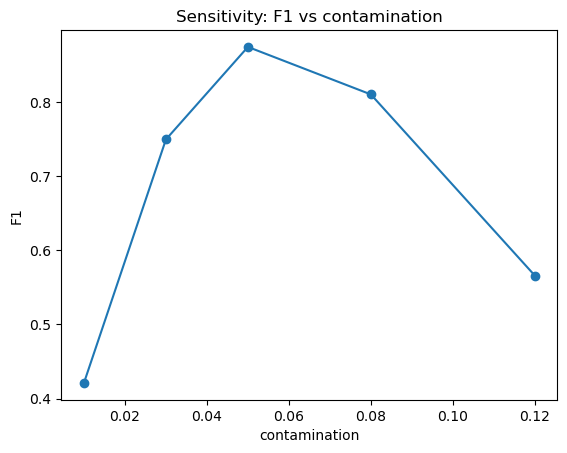

In [14]:
# Contamination
contamination_grid = [0.01, 0.03, 0.05, 0.08, 0.12]
results_contam = [
    fit_eval_iforest(X_train, X_test, y_test, contamination=c)
    for c in contamination_grid
]
res_contam_df = pd.DataFrame(results_contam).sort_values("contamination")
print("Sensitivity: contamination")
display(res_contam_df)

plt.figure()
plt.plot(res_contam_df["contamination"], res_contam_df["f1"], marker="o")
plt.title("Sensitivity: F1 vs contamination")
plt.xlabel("contamination")
plt.ylabel("F1")
plt.show()

Sensitivity analysis shows that the contamination parameter changes the balance between precision and recall. If contamination is set too low, the model misses many true anomalies. If it is set too high, it flags too many normal points as anomalies. The best performance occurs when contamination is close to the true anomaly rate (around 5%). The AUC stays almost the same across settings, which means the model separates normal and anomalous points very well regardless of the threshold.

Sensitivity: n_estimators


,contamination,n_estimators,max_samples,precision,recall,f1,auc,pred_outlier_rate
0,0.05,50,auto,0.875000,0.933333,0.903226,0.999556,0.050794
1,0.05,100,auto,0.933333,0.933333,0.933333,0.999333,0.047619
2,0.05,200,auto,0.933333,0.933333,0.933333,0.999333,0.047619
3,0.05,300,auto,0.823529,0.933333,0.875000,0.999333,0.053968
4,0.05,500,auto,0.823529,0.933333,0.875000,0.999333,0.053968


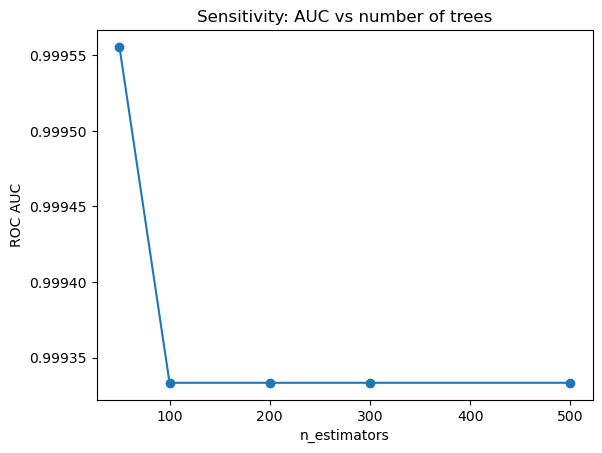

In [15]:
# N-estimators
n_estimators_grid = [50, 100, 200, 300, 500]
results_trees = [
    fit_eval_iforest(X_train, X_test, y_test, contamination=contamination_guess, n_estimators=n)
    for n in n_estimators_grid
]
res_trees_df = pd.DataFrame(results_trees).sort_values("n_estimators")
print("Sensitivity: n_estimators")
display(res_trees_df)

plt.figure()
plt.plot(res_trees_df["n_estimators"], res_trees_df["auc"], marker="o")
plt.title("Sensitivity: AUC vs number of trees")
plt.xlabel("n_estimators")
plt.ylabel("ROC AUC")
plt.show()

The performance is very stable. Precision, recall, F1, and AUC stay almost the same across 50 to 500 trees. This indicates that the model is not very sensitive to the number of trees.

Sensitivity: max_samples


,contamination,n_estimators,max_samples,precision,recall,f1,auc,pred_outlier_rate
0,0.05,300,0.3,0.823529,0.933333,0.875,0.999333,0.053968
1,0.05,300,0.6,0.823529,0.933333,0.875,0.999111,0.053968
2,0.05,300,1.0,0.823529,0.933333,0.875,0.999333,0.053968


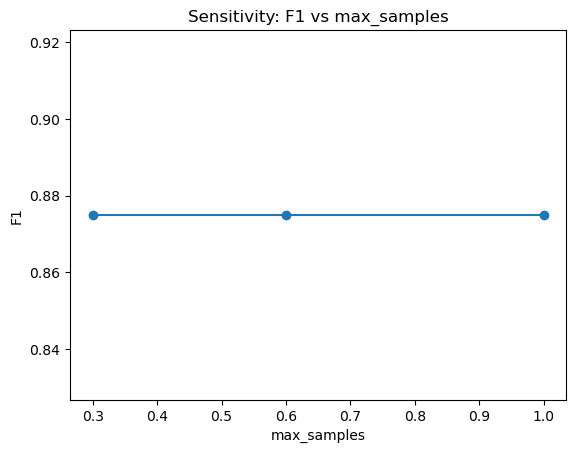

In [17]:
# Max samples
max_samples_grid = [0.3, 0.6, 1.0]
results_samples = [
    fit_eval_iforest(X_train, X_test, y_test, contamination=contamination_guess, n_estimators=300, max_samples=ms)
    for ms in max_samples_grid
]
res_samples_df = pd.DataFrame(results_samples).sort_values("max_samples")
print("Sensitivity: max_samples")
display(res_samples_df)

plt.figure()
plt.plot(res_samples_df["max_samples"], res_samples_df["f1"], marker="o")
plt.title("Sensitivity: F1 vs max_samples")
plt.xlabel("max_samples")
plt.ylabel("F1")
plt.show()

This output shows that changing max_samples has almost no effect on the model’s performance. Precision, recall, F1, and AUC remain nearly identical across 0.3, 0.6, and 1.0. The predicted outlier rate also stays the same. This means the model is not sensitive to how many samples are used per tree in this dataset.